<a href="https://colab.research.google.com/github/Racheal-Iperu/DIAML-assignment2/blob/main/riperu_DIAML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1) I will be using data from world bank to get the data for GDP per capita (current US).

part b) I used the library pandas data reader to download the data from worldbank data.

In [ ]:
import pandas as pd
from pandas_datareader import wb

#using the indicators provided in the data to retrieve the data, N:B - when parameters are not passed, there are default ones that are used.

reader = wb.WorldBankReader(
    symbols=["NY.GDP.PCAP.CD", "SH.STA.MALN.ZS"],
    start="1960",
    end="2026",
    countries= "all"
)

#reading data from the world bank object created above
df = reader.read()
df

NY.GDP.PCAP.CD  SH.STA.MALN.ZS
country     year                                
Afghanistan 1960             NaN             NaN
            1961             NaN             NaN
            1962             NaN             NaN
            1963             NaN             NaN
            1964             NaN             NaN
...                          ...             ...
Zimbabwe    2021     2613.616741             NaN
            2022     2536.401971             NaN
            2023     2195.225020             NaN
            2024     2496.155150             9.6
            2025     3021.430199             NaN

[17490 rows x 2 columns]

In [ ]:

#renaming columns for ease of manipulation

df = df.rename(columns={
    "NY.GDP.PCAP.CD": "GDP per capita",
    "SH.STA.MALN.ZS": "Underweight"
})
df

#Disagregating the data so that i have each record in it's own row.
df = df.reset_index()
df

#print(df["year"].min())
print(df["country"].unique())

df


<StringArray>
[                'Afghanistan', 'Africa Eastern and Southern',
  'Africa Western and Central',                     'Albania',
                     'Algeria',              'American Samoa',
                     'Andorra',                      'Angola',
         'Antigua and Barbuda',                  'Arab World',
 ...
                  'Uzbekistan',                     'Vanuatu',
               'Venezuela, RB',                    'Viet Nam',
       'Virgin Islands (U.S.)',          'West Bank and Gaza',
                       'World',                 'Yemen, Rep.',
                      'Zambia',                    'Zimbabwe']
Length: 265, dtype: string


,country,year,GDP per capita,Underweight
0,Afghanistan,1960,NaN,NaN
1,Afghanistan,1961,NaN,NaN
2,Afghanistan,1962,NaN,NaN
3,Afghanistan,1963,NaN,NaN
4,Afghanistan,1964,NaN,NaN
...,...,...,...,...
17485,Zimbabwe,2021,2613.616741,NaN
17486,Zimbabwe,2022,2536.401971,NaN
17487,Zimbabwe,2023,2195.225020,NaN
17488,Zimbabwe,2024,2496.155150,9.6


In [ ]:
#!pip install wbgapi

In [ ]:
#I used this for my comparison to check if both libraries return the same data
#import wbgapi as wb
#import pandas as pd

#test_df = wb.data.DataFrame(
 # ["NY.GDP.PCAP.CD", "SH.STA.MALN.ZS"],
 # economy=wb.economy.list(skipAggs=True), #this skips aggregate values that are added in the data by world bank
#)
#test_df
#economies = wb.economy.list()
#economy_info = wb.economy.info()

part b) Cleaning the data. First I noticed some data returned as countries are not actual countries, so i'll start by removing that.


In [ ]:
#getting list of all countries that are aggregates using the method countries, i retrieved all the countries data and noted that the field region specifies whether the name is an aggregate or actual country.

countries = reader.get_countries()
countries

# obtaining the list of all aggregates that is by returning the names where the region is called "Aggregate"
aggregates = countries[countries["region"] == "Aggregates"]["name"].tolist()
aggregates

#using the list of aggregates returned, i will remove any rows in the data that match the values of the aggregate. i filtered the dataframe to only return rows that are not in the aggregate data
df = df[~df["country"].isin(aggregates)]

#I noticed that there are values that have not been labelled as aggregate, so i will remove rows where the country name is the same as the region.
regions = countries["region"].dropna().str.strip().unique() #I had to use the strip method to remove any space before or after the country and region name to enable proper comparison.
print('regions', regions)

regions = df[df["country"].str.strip().isin(regions)].index
df.drop(regions, inplace=True)

print(df["country"].unique())
df

regions ['Latin America & Caribbean' 'Aggregates'
 'Middle East, North Africa, Afghanistan & Pakistan' 'Sub-Saharan Africa'
 'Europe & Central Asia' 'East Asia & Pacific' 'South Asia'
 'North America']
<StringArray>
[          'Afghanistan',               'Albania',               'Algeria',
        'American Samoa',               'Andorra',                'Angola',
   'Antigua and Barbuda',             'Argentina',               'Armenia',
                 'Aruba',
 ...
               'Uruguay',            'Uzbekistan',               'Vanuatu',
         'Venezuela, RB',              'Viet Nam', 'Virgin Islands (U.S.)',
    'West Bank and Gaza',           'Yemen, Rep.',                'Zambia',
              'Zimbabwe']
Length: 217, dtype: string


/tmp/ipykernel_1479/4013313083.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(regions, inplace=True)


,country,year,GDP per capita,Underweight
0,Afghanistan,1960,NaN,NaN
1,Afghanistan,1961,NaN,NaN
2,Afghanistan,1962,NaN,NaN
3,Afghanistan,1963,NaN,NaN
4,Afghanistan,1964,NaN,NaN
...,...,...,...,...
17485,Zimbabwe,2021,2613.616741,NaN
17486,Zimbabwe,2022,2536.401971,NaN
17487,Zimbabwe,2023,2195.225020,NaN
17488,Zimbabwe,2024,2496.155150,9.6


In [ ]:
# I noted many empty values for the underweight columns and since I am doing a comparison between GDP per capita and prevalence of underweight, I need to have both values to make this comaprison,
# I will therefore drop any data that does not have both values. So that I can remain with data with both fields and I can easily compare the two.
# I have not used interpolation to predict the prevalence of underweight values because the value keeps changing and may be affected by multiple factors. Forward filling would also not apply because
#the values are not always constant for humans and an absence of a value possibly means the survey or data collection was not done during that period.

#Removing rows with empty fields for either GDP per capita or prevalence of underweight.
df = df.dropna(subset=["GDP per capita", "Underweight"])
df

print(df['country'].nunique())

# obtaining the minimum and maximum year so that i can calculate the number of years left in my observation.
print('Minimum year', df['year'].min())
print('Maximum year', df['year'].max())

number_of_years = int(df['year'].max()) - int(df['year'].min())
number_of_years
df

161
Minimum year 1983
Maximum year 2024


,country,year,GDP per capita,Underweight
44,Afghanistan,2004,221.763654,31.7
53,Afghanistan,2013,637.087099,24.6
58,Afghanistan,2018,491.337221,19.1
62,Afghanistan,2022,357.261153,18.4
243,Albania,2005,2741.721365,6.6
...,...,...,...,...
17476,Zimbabwe,2012,1239.227097,11.1
17478,Zimbabwe,2014,1372.915262,11.2
17479,Zimbabwe,2015,1387.126326,8.5
17483,Zimbabwe,2019,2184.521554,9.7


part c) Here I will be plotting a scatter graph of malnutrition against GDP per capita

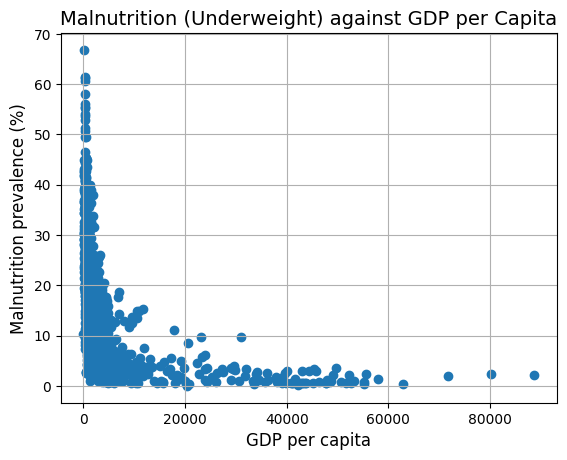

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['GDP per capita'],df['Underweight'])

plt.xlabel("GDP per capita",fontsize=12)
plt.ylabel("Malnutrition prevalence (%)",fontsize=12)
plt.title("Malnutrition (Underweight) against GDP per Capita",fontsize=14)
plt.grid()
plt.show()

#From the scatter plot, I noticed that with lower GDP, there were higher values of malnutrition and as the value for GDP per capita increased,
#there were lower values of malnutrion reported. The plot graph shows that my hypothesis was correct.

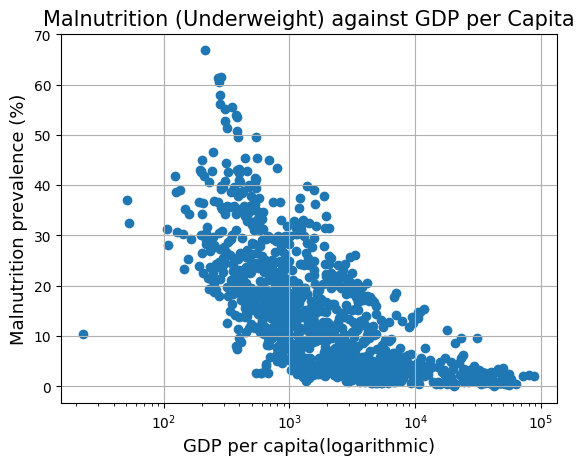

In [ ]:
# plotting the graph with GDP per capita on a logarithmic axis

plt.scatter(df['GDP per capita'],df['Underweight'])

plt.xscale('log') # transforming the x axis into a logarithmic value

plt.xlabel("GDP per capita(logarithmic)",fontsize=13)
plt.ylabel("Malnutrition prevalence (%)",fontsize=13)
plt.title("Malnutrition (Underweight) against GDP per Capita",fontsize=15)
plt.grid()
plt.show()

# I would publish the scatter graph with the logarithmic axis because the graph is clearer and shows the relationship between malnutrition and GDP per capita better. The first graph has
#most of the values clustered into one place making it hard to view the relationship.

part d) Plotting colored by Geographical region and income levels.

In [ ]:
#first I'll start by adding the regions and income level meta data into my dataframe to help me color according to geographical region and income level

countries

,iso3c,iso2c,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,,High income,Not classified,Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,,Aggregates,Aggregates,,NaN,NaN
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakis...",Low income,IDA,Kabul,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,,Aggregates,Aggregates,,NaN,NaN
4,AFW,ZI,Africa Western and Central,Aggregates,,Aggregates,Aggregates,,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
290,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,,Aggregates,Aggregates,,NaN,NaN
291,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakis...",Low income,IDA,Sana'a,44.2075,15.3520
292,ZAF,ZA,South Africa,Sub-Saharan Africa,Sub-Saharan Africa (excluding high income),Upper middle income,IBRD,Pretoria,28.1871,-25.7460
293,ZMB,ZM,Zambia,Sub-Saharan Africa,Sub-Saharan Africa (excluding high income),Lower middle income,IDA,Lusaka,28.2937,-15.3982


In [ ]:
#next i will merge the two data sets , such that i will find the country in my data frame and find the corresponding value in the countries data and return the region and income level.
metadata = countries[["name", "region", "incomeLevel"]]
df = df.merge(
    metadata,
    left_on="country",
    right_on="name",
    how="left"
)

df

# making sure that all the countries have been mapped to a region and there are no empty values
df_nan_any = df[df[['region', 'incomeLevel',]].isna().any(axis=1)]
df_nan_any

df


,country,year,GDP per capita,Underweight,name,region,incomeLevel
0,Afghanistan,2004,221.763654,31.7,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Afghanistan,2013,637.087099,24.6,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
2,Afghanistan,2018,491.337221,19.1,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,Afghanistan,2022,357.261153,18.4,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,Albania,2005,2741.721365,6.6,Albania,Europe & Central Asia,Upper middle income
...,...,...,...,...,...,...,...
1111,Zimbabwe,2012,1239.227097,11.1,Zimbabwe,Sub-Saharan Africa,Lower middle income
1112,Zimbabwe,2014,1372.915262,11.2,Zimbabwe,Sub-Saharan Africa,Lower middle income
1113,Zimbabwe,2015,1387.126326,8.5,Zimbabwe,Sub-Saharan Africa,Lower middle income
1114,Zimbabwe,2019,2184.521554,9.7,Zimbabwe,Sub-Saharan Africa,Lower middle income


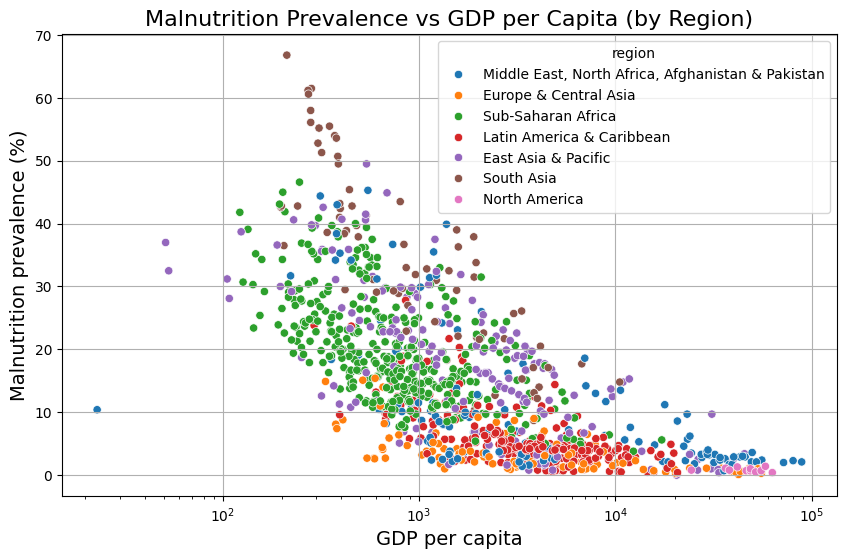

In [ ]:
#plotting and coloring by geopgraphical region
# I decided to use a logarithmic x axis to help me visualise the data better. Without it, the points are clustered up in one place and hard to see.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="GDP per capita",
    y="Underweight",
    hue="region"
)
plt.xscale("log")

plt.xlabel("GDP per capita",fontsize=14)
plt.ylabel("Malnutrition prevalence (%)",fontsize=14)
plt.title("Malnutrition Prevalence vs GDP per Capita (by Region)",fontsize=16)
plt.grid()
plt.show()

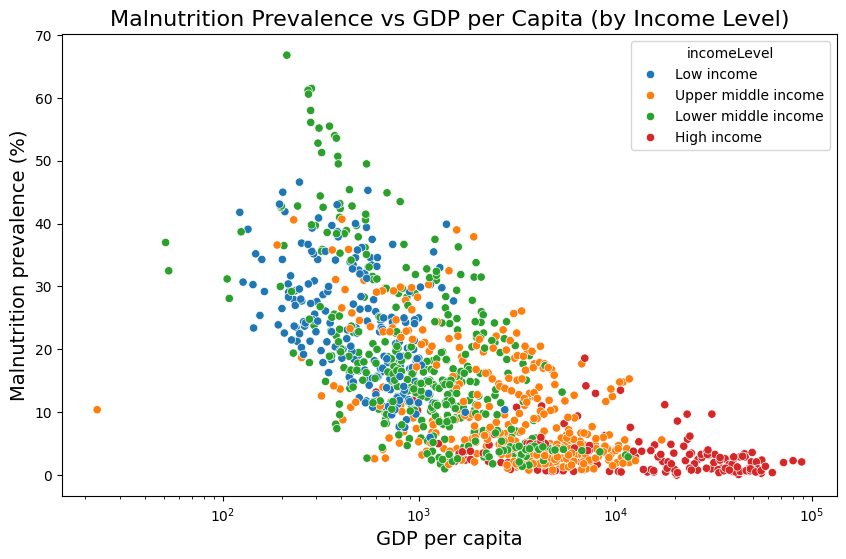

In [ ]:
#plotting and coloring by income level

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="GDP per capita",
    y="Underweight",
    hue="incomeLevel"
)
plt.xscale("log")

plt.xlabel("GDP per capita",fontsize=14)
plt.ylabel("Malnutrition prevalence (%)",fontsize=14)
plt.title("Malnutrition Prevalence vs GDP per Capita (by Income Level)",fontsize=16)
plt.show()

#The plot with colors is more informative beacuse now I can easily relate the region and income level to the levels of malnutirion against different GDP per capita levels.

part e) Here I will be plotting the number of observation each year. I will count how many countries reported data each year and then plot the number of observations against the years. I will use a line graph because i think it will help display the data better and show the trend.

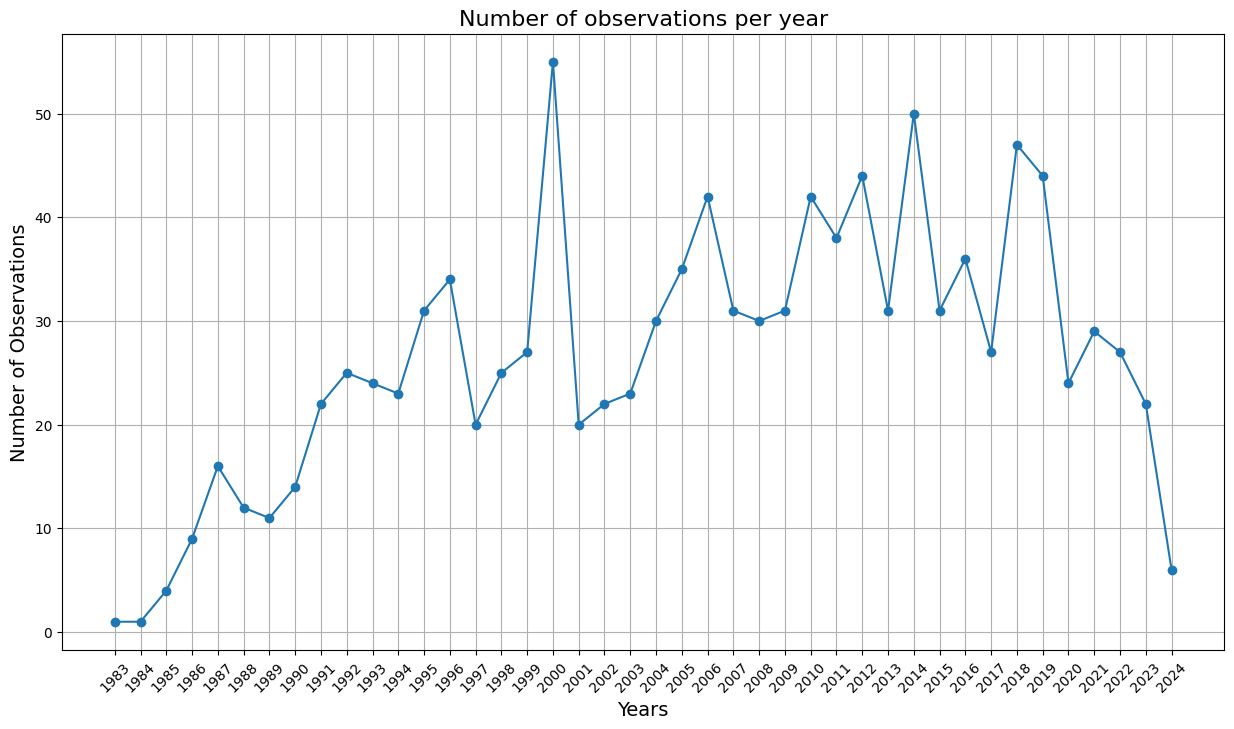

In [ ]:
# counting the number of observations per year

# I will group the data by years and then count how many unique countries are there per year, this will give me the number of countries that reported per year.
number_of_observations = df.groupby('year')['country'].count()
number_of_observations # this return a series with the year as index and the country column as the number of countries that reported in that year, therefore number of observations.

# next I will plot the line graph
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.plot(number_of_observations.index, number_of_observations.values, marker='o')
plt.xticks(number_of_observations.index, rotation=45)
plt.title('Number of observations per year',fontsize=16)
plt.xlabel('Years',fontsize=14)
plt.ylabel('Number of Observations',fontsize=14)
plt.grid(True)
plt.show()

#The line graph shows an initial increase in number of observations per year and then continuous decrease and increase between 1987 and 1999. In 2000, there was a peak with above 50 countries reportingand then a sharp drop in 2001.
#In the recent years from 2022 to 2024, I notice a decrease in observations made. The line graph generally shows that the reporting is not consistent.


Question two

part a) Using yfinance I will download the datasets on daily Closing price series for Wheat (ZW=F),Crude Oil (CL=F), and Gold (GC=F) from August 2000 to August 2026.

In [ ]:
#downloading the data from yfinance using an API. I will pass the arguments required for this download which are the tickers,start and end dates.
import yfinance as yf
import pandas as pd

tickers = ['ZW=F', 'CL=F', 'GC=F']
yFinanceData = yf.download(
    tickers,
    start='2000-08-1',
    end='2026-08-31',
  auto_adjust=False
)["Close"] # passing the Close value here so that the data returned is only for the closing values

df = pd.DataFrame(yFinanceData)
df

# Gold is quoted in troy ounce
# wheat in bushel
#crude oil in barrel

# renaming the columns to make analysis easier for me
df = df.rename(columns={
    'CL=F': 'Crude Oil',
    'GC=F': 'Gold',
    'ZW=F': 'Wheat'
})
df

[*********************100%***********************]  3 of 3 completed


Ticker,Crude Oil,Gold,Wheat
Date,,,
2000-08-01,NaN,NaN,245.00
2000-08-02,NaN,NaN,246.50
2000-08-03,NaN,NaN,242.25
2000-08-04,NaN,NaN,236.50
2000-08-07,NaN,NaN,233.50
...,...,...,...
2026-08-24,85.010002,4640.799805,681.75
2026-08-25,82.360001,4638.100098,685.50
2026-08-26,82.230003,4598.200195,730.50


In [ ]:
# for me to be able to apply forward fill, I'll find the common first date where all the tickers have values and use this as my data frame.
# To achieve this, I first dropped all the rows with any missing values, and then got the first date where all values were present. I used this date as my first common date and then dropped any value that came after that date.

first_common_date = df.dropna().index[0]
df = df.loc[first_common_date:]

df.isna().sum() #checking for nan values - returned values

#next i will drop all rows where the three indicators are nan since the question asked us to do a forward fill on where a value exists for one of the indicators but not the others.
df = df.dropna(subset=['Crude Oil', 'Gold', 'Wheat'], how='all')

#applying forward fill to the data to fill any nan values remaining where a value exists for one of the indicators but not the others

df = df.ffill()

df.isna().sum() #checking for nan values - returned 0

df

Ticker,Crude Oil,Gold,Wheat
Date,,,
2000-08-30,33.400002,273.899994,246.25
2000-08-31,33.099998,278.299988,251.00
2000-09-01,33.380001,277.000000,251.00
2000-09-05,33.799999,275.799988,250.25
2000-09-06,34.950001,274.200012,253.00
...,...,...,...
2026-08-24,85.010002,4640.799805,681.75
2026-08-25,82.360001,4638.100098,685.50
2026-08-26,82.230003,4598.200195,730.50


part b) Making prices comparable

In [ ]:
# I used base 100 indexing to normalise the different commodities. This choice preserves the daily percentage growths whereby if the actual value moved from 50 to 100, which is 100% growth, the smae will be reflected in the normalised value.
#Additionally, it preserves the historical spikes and falls and this can still be observed in the data when plotted.
#the choice however loses the actual values like the prices and one can not determine the raw price

#normalising the data by applying base 100 index. i will use the python. The formula for this is that i divide each value by the first value in the row and then multiple it by 100.
df_normalised = (df / df.iloc[0]) * 100
df_normalised

Ticker,Crude Oil,Gold,Wheat
Date,,,
2000-08-30,100.000000,100.000000,100.000000
2000-08-31,99.101787,101.606424,101.928934
2000-09-01,99.940118,101.131802,101.928934
2000-09-05,101.197598,100.693682,101.624365
2000-09-06,104.640716,100.109536,102.741117
...,...,...,...
2026-08-24,254.520953,1694.340967,276.852792
2026-08-25,246.586817,1693.355313,278.375635
2026-08-26,246.197604,1678.787988,296.649746


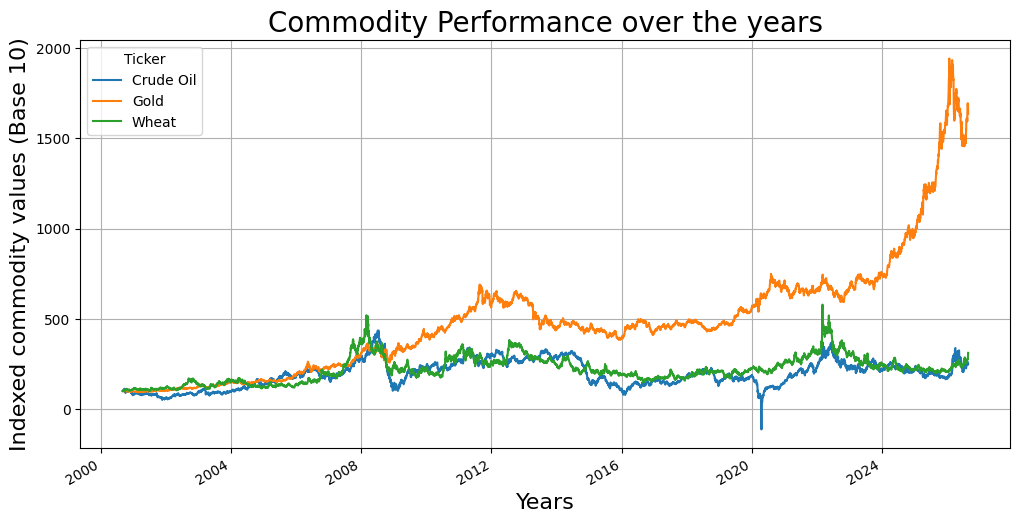

In [ ]:
#plotting three series on the same graph
import matplotlib.pyplot as plt

df_normalised.plot(figsize=(12, 6))
plt.title("Commodity Performance over the years",fontsize=20)
plt.xlabel("Years",fontsize=16)
plt.ylabel("Indexed commodity values (Base 10)",fontsize=16)
plt.grid(True)
plt.show()


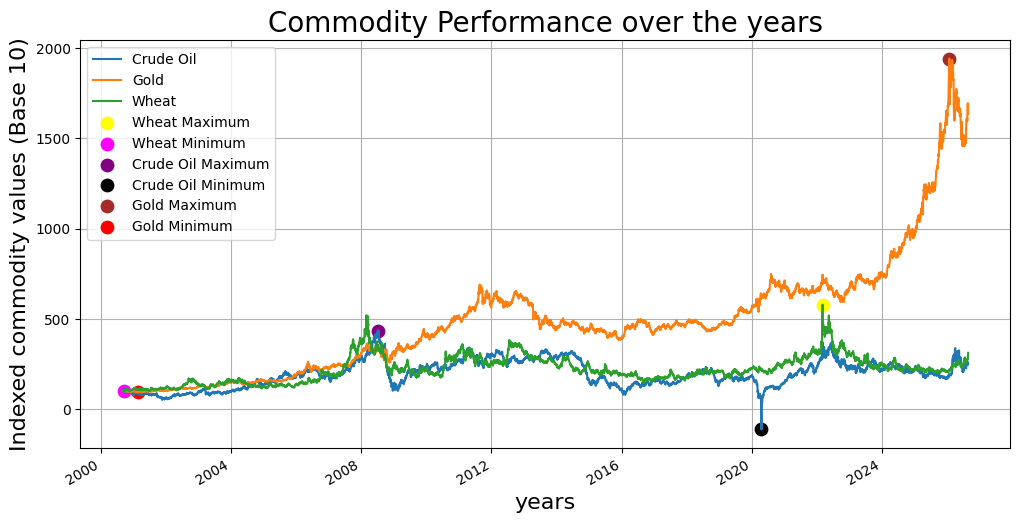

In [ ]:
## part c) Adding markers
# I'll start by identifying the minimum and maximum values in each commodity and then I will plot them onto the graph.

import matplotlib.pyplot as plt

ax = df_normalised.plot(figsize=(12, 6))

# defining colors for each commodity
colors = {
    'Wheat': {'max': 'yellow', 'min': 'magenta'},
    'Crude Oil': {'max': 'purple', 'min': 'black'},
    'Gold': {'max': 'brown', 'min': 'red'}
}

# Finding the maximum and minimum of each commodity
for commodity in ['Wheat', 'Crude Oil', 'Gold']:

    # Maximum values for the commodities
    max_date = df_normalised[commodity].idxmax()
    max_val = df_normalised[commodity].max()

    ax.scatter(
        max_date, max_val,
        color=colors[commodity]['max'],
        s=80,
        label=f'{commodity} Maximum'
    )

    # Minimum values for the commodities
    min_date = df_normalised[commodity].idxmin()
    min_val = df_normalised[commodity].min()

    ax.scatter(
        min_date, min_val,
        color=colors[commodity]['min'],
        s=80,
        label=f'{commodity} Minimum'
    )


ax.set_title('Commodity Performance over the years',fontsize=20)
ax.set_xlabel('years',fontsize=16)
ax.set_ylabel('Indexed commodity values (Base 10)',fontsize=16)

ax.legend()
plt.grid(True)
plt.show()

part d) I will replot the graph using the un_normalised data to determine how the graphs are affected

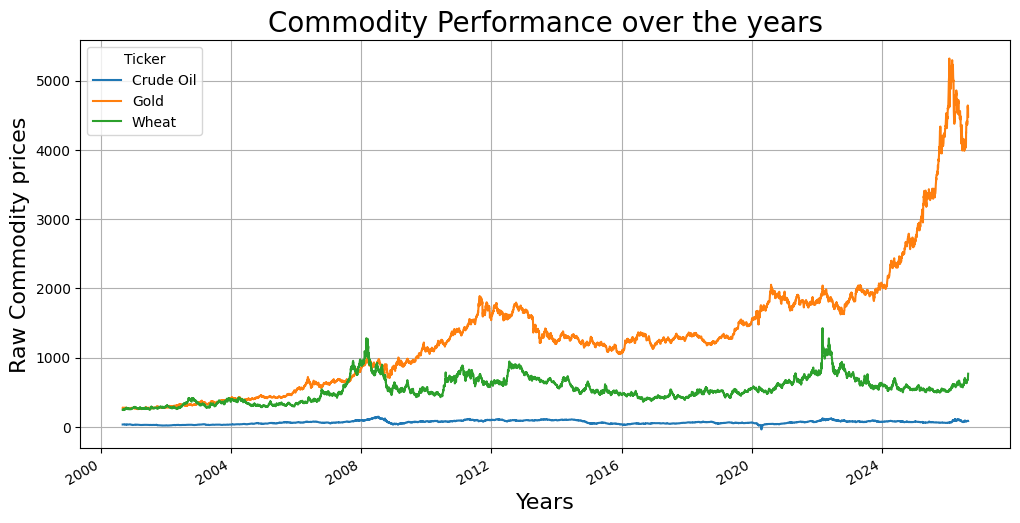

In [ ]:
#plotting three series that are not normalised on the same graph to compare how the shape and comparison between them differs
import matplotlib.pyplot as plt

df.plot(figsize=(12, 6))
plt.title("Commodity Performance over the years",fontsize=20)
plt.xlabel("Years",fontsize=16)
plt.ylabel("Raw Commodity prices",fontsize=16)
plt.grid(True)
plt.show()

#From the graph i noted that plotting the unnormalised values affects both the shape and the comparison between the three series. The crude oil series in paprticular has
#changed it's shape and it's tending towards a straight line. The crude oil prices also seem much more lower and not comparing to the other series.

part e) Re-performing parts a to c using inner join.

In [ ]:

# I am redownloading the data to make sure I have not tempered with the original form of the data.

#downloading the data from yfinance using an API. I will pass the arguments required for this download which are the tickers,start and end dates. Inorder to use the inner join function, I had to download the data separately and the
#merge it using inner join
import yfinance as yf
import pandas as pd

wheat = yf.download(
    'ZW=F',
    start='2000-08-01',
    end='2026-08-31',
    auto_adjust=False
)['Close']

oil = yf.download(
    'CL=F',
    start='2000-08-01',
    end='2026-08-31',
    auto_adjust=False
)['Close']

gold = yf.download(
    'GC=F',
    start='2000-08-01',
    end='2026-08-31',
    auto_adjust=False
)['Close']

wheat.name = 'Wheat'
oil.name = 'Crude Oil'
gold.name = 'Gold'


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# part a) reperformance
#The inner join method drops any value for which any of the series is nan. Therefore i will drop any row where there is a nan and only remain with data where all the three series have values.
df = pd.concat(
    [oil, gold,wheat],
    axis=1,
    join='inner'
)

# renaming the columns to make analysis easier for me
df = df.rename(columns={
    'CL=F': 'Crude Oil',
    'GC=F': 'Gold',
    'ZW=F': 'Wheat'
})

df = df.dropna()

df


Ticker,Crude Oil,Gold,Wheat
Date,,,
2000-08-30,33.400002,273.899994,246.25
2000-08-31,33.099998,278.299988,251.00
2000-09-01,33.380001,277.000000,251.00
2000-09-05,33.799999,275.799988,250.25
2000-09-06,34.950001,274.200012,253.00
...,...,...,...
2026-08-24,85.010002,4640.799805,681.75
2026-08-25,82.360001,4638.100098,685.50
2026-08-26,82.230003,4598.200195,730.50


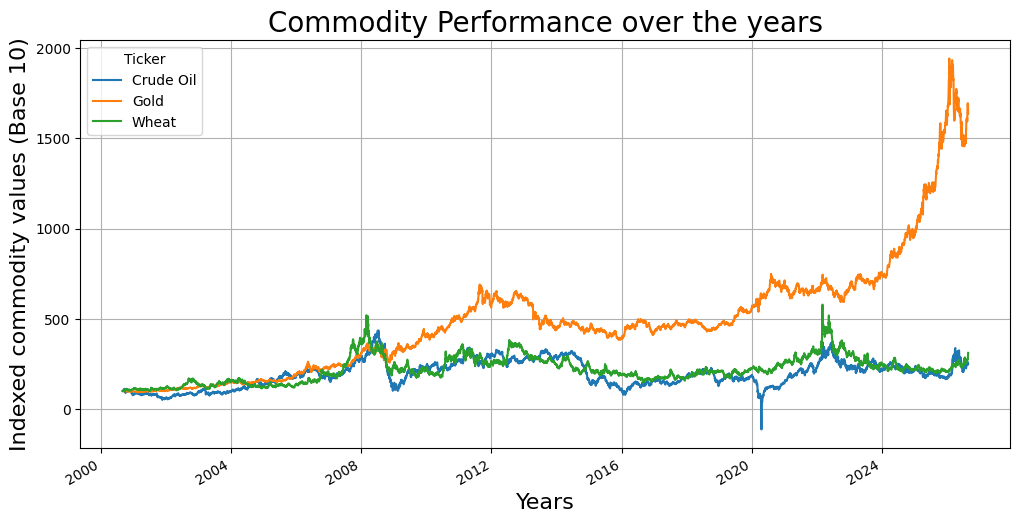

In [ ]:
#part b) reperformance

# I used base 100 indexing to normalise the different commodities. This choice preserves the daily percentage growths whereby if the actual value moved from 50 to 100, which is 100% growth, the smae will be reflected in the normalised value.
#Additionally, it preserves the historical spikes and falls and this can still be observed in the data when plotted.
#the choice however loses the actual values like the prices and one can not determine the raw price

#normalising the data by applying base 100 index. i will use the python. The formula for this is that i divide each value by the first value in the row and then multiple it by 100.
df_normalised = (df / df.iloc[0]) * 100
df_normalised

#plotting three series on the same graph
import matplotlib.pyplot as plt

df_normalised.plot(figsize=(12, 6))
plt.title("Commodity Performance over the years",fontsize=20)
plt.xlabel("Years",fontsize=16)
plt.ylabel("Indexed commodity values (Base 10)",fontsize=16)
plt.grid(True)
plt.show()


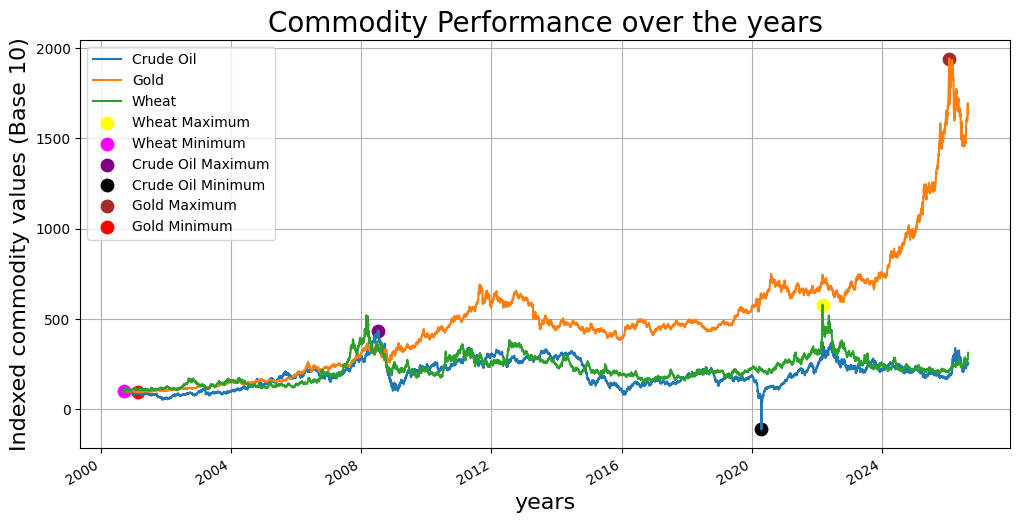

In [ ]:
#part c) Reperformance
## part c) Adding markers
# I'll start by identifying the minimum and maximum values in each commodity and then I will plot them onto the graph.

import matplotlib.pyplot as plt

ax = df_normalised.plot(figsize=(12, 6))

# defining colors for each commodity
colors = {
    'Wheat': {'max': 'yellow', 'min': 'magenta'},
    'Crude Oil': {'max': 'purple', 'min': 'black'},
    'Gold': {'max': 'brown', 'min': 'red'}
}

# Finding the maximum and minimum of each commodity
for commodity in ['Wheat', 'Crude Oil', 'Gold']:

    # Maximum values for the commodities
    max_date = df_normalised[commodity].idxmax()
    max_val = df_normalised[commodity].max()

    ax.scatter(
        max_date, max_val,
        color=colors[commodity]['max'],
        s=80,
        label=f'{commodity} Maximum'
    )

    # Minimum values for the commodities
    min_date = df_normalised[commodity].idxmin()
    min_val = df_normalised[commodity].min()

    ax.scatter(
        min_date, min_val,
        color=colors[commodity]['min'],
        s=80,
        label=f'{commodity} Minimum'
    )


ax.set_title('Commodity Performance over the years',fontsize=20)
ax.set_xlabel('years',fontsize=16)
ax.set_ylabel('Indexed commodity values (Base 10)',fontsize=16)

ax.legend()
plt.grid(True)
plt.show()

QUESTION THREE

part a) I will be using the pandas data reader library to read the data from world bank API. Basing on the proceeding question formats, I will download the data for each indicator separately and clean it separately. That way dropping a row in one data set will not affect the other.

In [ ]:
import pandas as pd
from pandas_datareader import wb

#this creates an object that i can use to read the data from world bank API.
reader_children = wb.WorldBankReader(
    symbols=["SE.PRM.UNER.ZS"],
    start="2022",
    end="2022",
    countries= "all"
)

reader_adolescents = wb.WorldBankReader(
    symbols=["SE.SEC.UNER.LO.ZS"],
    start="2022",
    end="2022",
    countries= "all"
)

#reading data from the world bank object created above
df_children = reader_children.read()
df_adolescents = reader_adolescents.read()
df_children



,,SE.PRM.UNER.ZS
country,year,
Africa Eastern and Southern,2022,NaN
Africa Western and Central,2022,NaN
Arab World,2022,NaN
Caribbean small states,2022,NaN
Central Europe and the Baltics,2022,NaN
...,...,...
Virgin Islands (U.S.),2022,NaN
West Bank and Gaza,2022,9.507215
"Yemen, Rep.",2022,NaN


In [ ]:
#for each line and manipulation, I will be doing it twice, one for children and the other for adults. This way I will be able to answer the question on how many valid countries remain in each series.
# renaming columns to make it easier to work with
df_children = df_children.rename(columns={
    'SE.PRM.UNER.ZS': 'Children out',
})
df

df_adolescents = df_adolescents.rename(columns={
    'SE.SEC.UNER.LO.ZS': 'Adolescents out'
})


#next I will have all my values as rows rather than the country and year as index
df_children = df_children.reset_index()
df_adolescents = df_adolescents.reset_index()


# To clean my data, I'll start first by removing aggregate or regions from the data so that I can remain with distinct countries.
#To achieve this, I'll get the list of all countries that has meta data about each country and then use to identify the value that is a region/aggregation and remove it from the data

countries = reader.get_countries()
countries

# obtaining the list of all aggregates that is by returning the names where the region is called "Aggregate"
aggregates = countries[countries["region"] == "Aggregates"]["name"].tolist()
aggregates
print('aggregates', aggregates)

#using the list of aggregates returned, i will remove any rows in the data that match the values of the aggregate. i filtered the dataframe to only return rows that are not in the aggregate data
df_children = df_children[~df_children["country"].isin(aggregates)]
df_adolescents = df_adolescents[~df_adolescents["country"].isin(aggregates)]

#I noticed that there are values that have not been labelled as aggregate, so i will remove rows where the country name is the same as the region.
regions = countries["region"].dropna().str.strip().unique() #I had to use the strip method to remove any space before or after the country and region name to enable proper comparison.
#print('regions', regions)

#cleaning children
regions_children = df_children[df_children["country"].str.strip().isin(regions)].index
df_children.drop(regions_children, inplace=True)

#cleaning adolescents
regions_adolescents = df_adolescents[df_adolescents["country"].str.strip().isin(regions)].index
df_adolescents.drop(regions_adolescents, inplace=True)

df_adolescents

aggregates ['Africa Eastern and Southern', 'Africa', 'Africa Western and Central', 'Arab World', 'East Asia & Pacific (IBRD-only countries)', 'Europe & Central Asia (IBRD-only countries)', 'IBRD countries classified as high income', 'Latin America & the Caribbean (IBRD-only countries)', 'Middle East, North Africa, Afghanistan & Pakistan (IBRD only)', 'Sub-Saharan Africa (IBRD-only countries)', 'Sub-Saharan Africa (IFC classification)', 'East Asia and the Pacific (IFC classification)', 'Central Europe and the Baltics', 'Europe and Central Asia (IFC classification)', 'Latin America and the Caribbean (IFC classification)', 'Middle East and North Africa (IFC classification)', 'South Asia (IFC classification)', 'Caribbean small states', 'East Asia & Pacific (IDA-eligible countries)', 'Europe & Central Asia (IDA-eligible countries)', 'Latin America & the Caribbean (IDA-eligible countries)', 'Middle East, North Africa, Afghanistan & Pakistan (IDA total)', 'IDA countries in Sub-Saharan Africa 

,country,year,Adolescents out
48,Afghanistan,2022,NaN
49,Albania,2022,2.749650
50,Algeria,2022,6.207080
51,American Samoa,2022,NaN
52,Andorra,2022,6.199460
...,...,...,...
260,Virgin Islands (U.S.),2022,NaN
261,West Bank and Gaza,2022,5.048327
262,"Yemen, Rep.",2022,NaN
263,Zambia,2022,NaN


In [ ]:
#next for each series, I will drop the rows where the value is nan since this indicates the data was not reported that country in 2022 and could affect our caluculations
df_children = df_children.dropna()
df_adolescents = df_adolescents.dropna()

df_children

df_adolescents


,country,year,Adolescents out
49,Albania,2022,2.749650
50,Algeria,2022,6.207080
52,Andorra,2022,6.199460
54,Antigua and Barbuda,2022,5.633647
55,Argentina,2022,0.995725
...,...,...,...
257,Vanuatu,2022,2.614305
258,"Venezuela, RB",2022,1.141590
259,Viet Nam,2022,4.262073
261,West Bank and Gaza,2022,5.048327


In [ ]:
# to avoid double counting, first i removed the rows that represented aggregate, regional and world data. Next, I will check each series to ensure that each country reported values only one in the year 2022
print('duplicated adolescents',df_adolescents.duplicated().sum())
print('duplicated children',df_children.duplicated().sum())

#both returned 0 meaning each country reported only once

# 145  valid countries remained for each series. To avoid statistical bias,


duplicated adolescents 0
duplicated children 0


part b) Here I will be calculating the mean,median, standard deviation and the percentiles.



In [ ]:
# Calculating the required matrix for the two indicators. Since my data in in separate series, I will combine it into a single dataframe and then i can change this into a table

import pandas as pd

stats_table = pd.DataFrame({
    "Children out of school": [
        df_children["Children out"].mean(),
        df_children["Children out"].median(),
        df_children["Children out"].std(),
        df_children["Children out"].quantile(0.05),
        df_children["Children out"].quantile(0.25),
        df_children["Children out"].quantile(0.75),
        df_children["Children out"].quantile(0.95)
    ],
    "Adolescents out of school": [
        df_adolescents["Adolescents out"].mean(),
        df_adolescents["Adolescents out"].median(),
        df_adolescents["Adolescents out"].std(),
        df_adolescents["Adolescents out"].quantile(0.05),
        df_adolescents["Adolescents out"].quantile(0.25),
        df_adolescents["Adolescents out"].quantile(0.75),
        df_adolescents["Adolescents out"].quantile(0.95)
    ]
}, index=[
    "Mean",
    "Median",
    "Standard deviation",
    "5th percentile",
    "25th percentile",
    "75th percentile",
    "95th percentile"
])

stats_table.round(4)

#used below for comparison
#summary = df_children["Children out"].describe(percentiles=[0.05, 0.25, 0.75, 0.95])
#print(summary)
#print(stats_table.round(2))

#effect on skewedness
# for children out of school, the mean is greater than the median meaning we have more data is clustered to the left (lower end) this would create a positive(right) skew and then for
#Adolescent out of school , the same is happening, the mean is greater that the median though with a bigger difference, meaning more data is clustered to the left and therefore a positve(right) skew is created

,Children out of school,Adolescents out of school
Mean,7.2813,11.0207
Median,3.0397,4.7709
Standard deviation,9.7941,15.4050
5th percentile,0.0991,0.1423
25th percentile,1.1035,1.2980
75th percentile,8.4780,12.7908
95th percentile,29.7153,47.0781


part c) Comparison of interquartile range

In [ ]:
#I will compare the interquartile range and upper tail spread by subtracting the different ranges as provided in the question
#(IQR = P75 - P25) and (P95 - P75)
#I will be using the different values of percentiles calculated in part b) of the question

#calculation for children
IQR_children = 8.4780 - 1.1035
upper_tail_children = 29.7153 - 8.4780

print('IQR for children',round(IQR_children,4))
print('Upper tail for children',round(upper_tail_children,4))

#calculation for adolescents
IQR_adolescents = 12.7908 - 1.2980
upper_tail_adolescents = 47.0781 - 12.7908

print('IQR for adolescents',round(IQR_adolescents,4))
print('Upper tail for adolescents',round(upper_tail_adolescents,4))




IQR for children 7.3745
Upper tail for children 21.2373
IQR for adolescents 11.4928
Upper tail for adolescents 34.2873


QUESTION FOUR

part a)Here I will extract the data and remove any aggregates to only remain with the countries.

In [ ]:
import pandas as pd
from pandas_datareader import wb

# I will extract the two different years separately and then merge the datasets into a single data frame for manipulation.
#using the indicators provided in the question to retrieve the data, N:B - when parameters are not passed, there are default ones that are used.

#starting with 2000
reader_2000 = wb.WorldBankReader(
    symbols=["SP.DYN.TFRT.IN", "NY.GDP.PCAP.CD"],
    start="2000",
    end="2000",
    countries="all"
)

#reading data from the world bank object created above
df_2000 = reader_2000.read()

df_2000 = df_2000.rename(columns={
    'SP.DYN.TFRT.IN': 'Fertility Rate',
    'NY.GDP.PCAP.CD': 'GDP per capita'
})

df_2000 = df_2000.reset_index()

df_2000['Year'] = 2000

#extracting 2020
reader_2020 = wb.WorldBankReader(
    symbols=["SP.DYN.TFRT.IN", "NY.GDP.PCAP.CD"],
    start="2020",
    end="2020",
    countries="all"
)

df_2020 = reader_2020.read()

df_2020 = df_2020.rename(columns={
    'SP.DYN.TFRT.IN': 'Fertility Rate',
    'NY.GDP.PCAP.CD': 'GDP per capita'
})

df_2020 = df_2020.reset_index()

df_2020['Year'] = 2020

#merging the two data sets to have one. This way I can clean both data sets at once

df = pd.concat([df_2000, df_2020], ignore_index=True)

df

,country,year,Fertility Rate,GDP per capita,Year
0,Afghanistan,2000,7.566000,174.930991,2000
1,Africa Eastern and Southern,2000,5.549893,706.728441,2000
2,Africa Western and Central,2000,6.023370,519.642600,2000
3,Albania,2000,2.217000,1160.420471,2000
4,Algeria,2000,2.590000,1772.928691,2000
...,...,...,...,...,...
525,West Bank and Gaza,2020,3.511000,3233.568638,2020
526,World,2020,2.276230,10999.491758,2020
527,"Yemen, Rep.",2020,4.600000,NaN,2020
528,Zambia,2020,4.323000,951.644317,2020


In [ ]:
#here I will remove all rows that are not actual countries but aggregates

#getting list of all countries that are aggregates using the method countries, i retrieved all the countries data and noted that the field region specifies whether the name is an aggregate or actual country.

countries = reader.get_countries()
countries

# obtaining the list of all aggregates that is by returning the names where the region is called "Aggregate"
aggregates = countries[countries["region"] == "Aggregates"]["name"].tolist()
aggregates

#using the list of aggregates returned, i will remove any rows in the data that match the values of the aggregate. i filtered the dataframe to only return rows that are not in the aggregate data
df = df[~df["country"].isin(aggregates)]

#I noticed that there are values that have not been labelled as aggregate, so i will remove rows where the country name is the same as the region.
regions = countries["region"].dropna().str.strip().unique() #I had to use the strip method to remove any space before or after the country and region name to enable proper comparison.

regions = df[df["country"].str.strip().isin(regions)].index
df.drop(regions, inplace=True)
#df['country'].nunique()
df

/tmp/ipykernel_1479/3980344092.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(regions, inplace=True)


,country,year,Fertility Rate,GDP per capita,Year
0,Afghanistan,2000,7.566,174.930991,2000
3,Albania,2000,2.217,1160.420471,2000
4,Algeria,2000,2.590,1772.928691,2000
5,American Samoa,2000,3.890,NaN,2000
6,Andorra,2000,1.273,21810.248743,2000
...,...,...,...,...,...
524,Virgin Islands (U.S.),2020,2.030,39787.374165,2020
525,West Bank and Gaza,2020,3.511,3233.568638,2020
527,"Yemen, Rep.",2020,4.600,NaN,2020
528,Zambia,2020,4.323,951.644317,2020


In [ ]:
#checking for nan values
df.isna().sum() #138 empty coulumns in the GDP per capita column

# I noticed that the empty values are in the GDP per capita column. I will drop the columns where GDP per capita is empty because using an interpolation method like forward fill
#would be introducing fictional data and yet GDP per capita changes annually. Therefore it seems like a safer option to use the existing data to perform the comaprisons. I believe this would give me more
#accurate results for this comparison than carrying forward values which would be creating a false relationship between fertility and GDP.
df = df.dropna()
df.isna().sum()

,0
country,0
year,0
Fertility Rate,0
GDP per capita,0
Year,0


part b) I will be plotting a scatter graph for Fertility Rate vs. GDP per Capita for 2020 using the linear and log axis

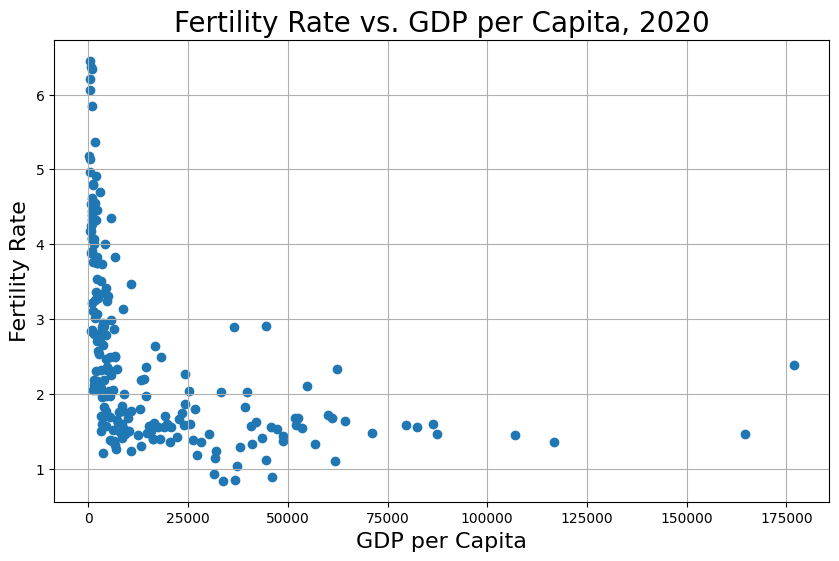

In [ ]:
#first I will create a copy of the data with only 2020 data and then plot a scatter graph for this data.
df_2020 = df[df['year'] == '2020'].copy()

#Using linear axis
#I will be plotting two graphs, one for linear axis and the other log axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_2020['GDP per capita'],
    df_2020['Fertility Rate']
)

plt.xlabel('GDP per Capita',fontsize=16)
plt.ylabel('Fertility Rate',fontsize=16)
plt.title('Fertility Rate vs. GDP per Capita, 2020',fontsize=20)
plt.grid()
plt.show()


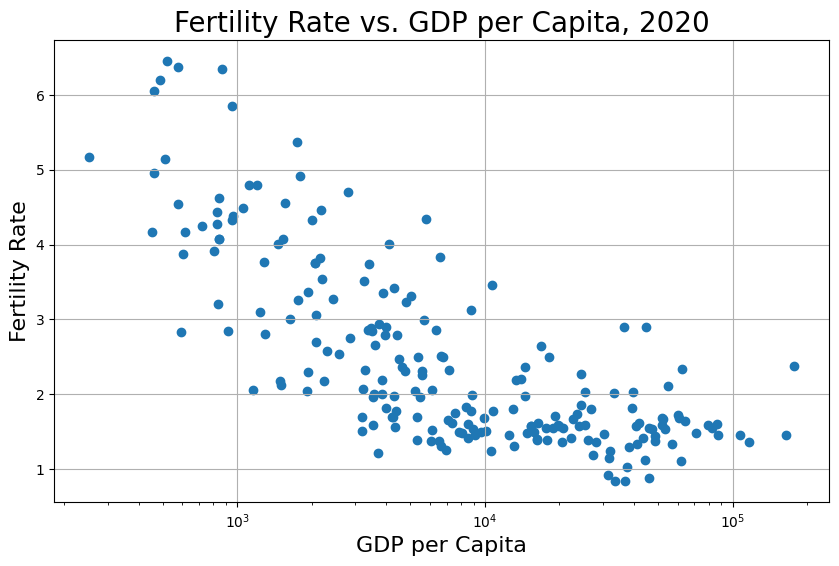

In [ ]:
#plotting the same graph above but using a logarithmic x axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_2020['GDP per capita'],
    df_2020['Fertility Rate']
)
plt.xscale('log') #transforming x-axis to log value

plt.xlabel('GDP per Capita',fontsize=16)
plt.ylabel('Fertility Rate',fontsize=16)
plt.title('Fertility Rate vs. GDP per Capita, 2020',fontsize=20)
plt.grid()
plt.show()

part c) The linear scale is inadequate for GDP per capita because a few countries have a very high GDP while majority are extremely low. Using a linear causes most of the countries to be clustered in one corner in this case the left hand side of the graph. It is therefore hard to see the actual relationship these countries have with GDP. Using a log x-axis helps display the GDP in a way that the ranges are not so apart, so similar GDPs are within the same scale and this way the relationship between GDP and fertility for each country is easier to see.

From the graph, I noticed that as GDP increases, the fertility rate decreases. The graph shows countries with lower GDp have higher fertility rate.

part d) Here I will be plotting CDF curves for 2000 and 2020 data. And then I will add a mean and median on the graphs for each of the year CDF curves.

In [ ]:
#I will start by getting a copy of 2000 data only. I already got the one for 2020 in part b) above
df_2000 = df[df['year'] == '2000']
df_2000

# I will then calculate the CDF values for the corresponding years
import numpy as np

x_2000 = np.sort(df_2000['Fertility Rate']) # we sort because CDF requires ordered values to be able to calculate the values less or equal to each specific value
x_2020 = np.sort(df_2020['Fertility Rate'])

y_2000 = np.arange(1, len(x_2000) + 1) / len(x_2000)
y_2020 = np.arange(1, len(x_2020) + 1) / len(x_2020)

#I will then calculate the means and medians
mean_2000 = df_2000['Fertility Rate'].mean()
median_2000 = df_2000['Fertility Rate'].median()

mean_2020 = df_2020['Fertility Rate'].mean()
median_2020 = df_2020['Fertility Rate'].median()

print('mean 2000 = ',round(mean_2000,4),'\n')
print('mean 2000 = ',round(median_2000,4),'\n')
print('mean 2020 = ',round(mean_2020,4),'\n')
print('mean 2020 = ',round(median_2020,4),'\n')

mean 2000 =  3.21 

mean 2000 =  2.6935 

mean 2020 =  2.4796 

mean 2020 =  2.0315 



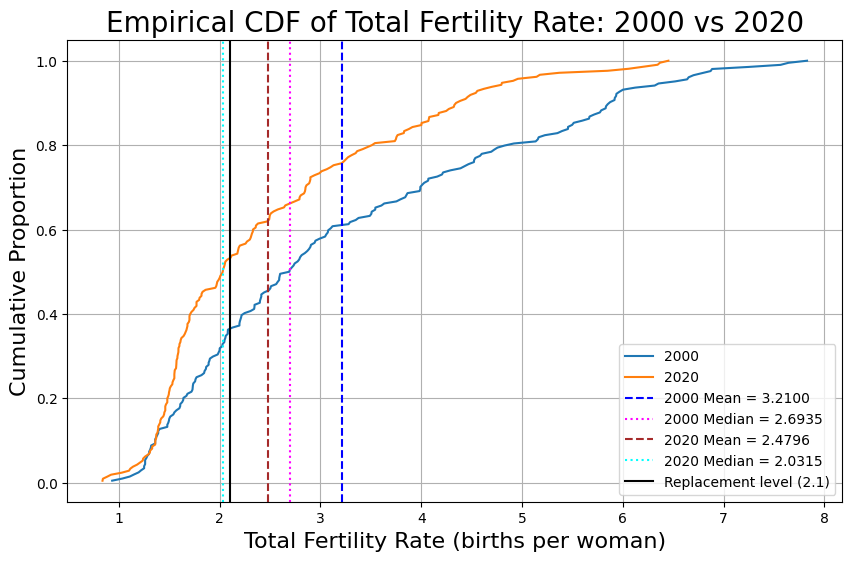

In [ ]:
#Using the values created aboved, I will plot the CDF graphs

# Create the graph
plt.figure(figsize=(10, 6))

# CDF curves
plt.plot(x_2000, y_2000, label='2000')
plt.plot(x_2020, y_2020, label='2020')

# Mean and median lines
plt.axvline(mean_2000, linestyle='--',color='blue', label=f'2000 Mean = {mean_2000:.4f}')
plt.axvline(median_2000, linestyle=':', color='magenta', label=f'2000 Median = {median_2000:.4f}')

plt.axvline(mean_2020, linestyle='--',color='brown', label=f'2020 Mean = {mean_2020:.4f}')
plt.axvline(median_2020, linestyle=':',color='cyan', label=f'2020 Median = {median_2020:.4f}')

#adding a line 2.1 on the graph to help me answer question part e)
plt.axvline(2.1, linestyle='-',color='black', label='Replacement level (2.1)')

# Labels and formatting
plt.xlabel('Total Fertility Rate (births per woman)',fontsize=16)
plt.ylabel('Cumulative Proportion',fontsize=16)
plt.title('Empirical CDF of Total Fertility Rate: 2000 vs 2020',fontsize=20)
plt.legend()
plt.grid(True)

plt.show()

part e)

part f)

QUESTION FIVE

part a) Downloading and adding the excels into my note book. I uploaded the excels to github so that they can be easily accessible when someoneelse is running the notebook file.

In [ ]:
#adding the urls for the data sets
cpi_url = "https://raw.githubusercontent.com/Racheal-Iperu/DIAML-assignment2/main/CPI2025_Results.xlsx"
hpi_url = "https://raw.githubusercontent.com/Racheal-Iperu/DIAML-assignment2/main/Happy-Planet-Index-2006-2025-public-data-set.xlsx"
#cpi_url = '/content/CPI2025_Results.xlsx'
#checking for sheet names to be able to pass the right values for sheet_name
print("HPI sheets:")
print(pd.ExcelFile(hpi_url).sheet_names)

print("\nCPI sheets:")
print(pd.ExcelFile(cpi_url).sheet_names)

#Then i will access the data using pandas. Since there are multiple sheets in the excel, I will specify which sheet I will be working with.
hpi = pd.read_excel(hpi_url, sheet_name="1. All countries",header=8)
cpi = pd.read_excel(cpi_url, sheet_name="CPI2025",header=3)


HPI sheets:
['Intro', '1. All countries', '2. Country Grapher', '4. Gender differences', '5. Data Sources', 'Cont data', 'All Data', 'country codes', 'Lookups']

CPI sheets:
['CPI2025', 'CPI Timeseries 2012 - 2025', 'CPI 2025 Regional Averages', 'Significant Changes since 2012 ', 'CPI 2025 Trends', 'CPI Historical']


In [ ]:
#Before proceeding to use the data, I will clean it to ensure I have better data quality for my proceeding questions. I started by inspecting my downloaded excels and reviewing the questions that the data needs to answer in the
#assignment and noted that the important columns are hpi rank, hpi score, the components of hpi, cpi rank and cpi score. Using this information, I checked for any empty fields in these columns and noted that the hpi score was empty for some countries and for each row where
#the hpi score was empty, there was some missing value in it's components. I noted however that the cpi data had all the required values for the calculations.
#In order to clean my data, I dropped the rows in the hpi data where the fields were empty. I did this because I was using data for just one year for each indicator and each country reports only once. Additionally, the empty values were only 21 rows would would not affect the
#calculation of correlation between hpi and cpi. The remaining data was sufficient to show this correlation.
hpi = hpi.dropna(subset=['HPI'])

In [ ]:
# Here I will be merging the data by country name
merge_country = pd.merge(
    hpi,
    cpi,
    left_on="Country",
    right_on="Country / Territory",
    how="inner"
)

#checking the number of countries that matched by getting the length of the rows in the data
print("Countries matched:", len(merge_country))

#next I will calculate the number of countries that were dropped in each data set. Here I'll get the unique countries in each dataset and then compare with the final data set to check which countries were not returned
hpi_unmatched_country = hpi[~hpi["Country"].isin(merge_country["Country"])]

cpi_unmatched_country = cpi[~cpi["Country / Territory"].isin(merge_country["Country"])]

print("HPI countries dropped:", hpi_unmatched_country["Country"].nunique())
print("CPI countries dropped:", cpi_unmatched_country["Country / Territory"].nunique())


Countries matched: 130
HPI countries dropped: 4
CPI countries dropped: 52


In [ ]:
#Next I will merge the datasets by iso values and then also count the number of rows that were dropped in each country
merge_ISO = pd.merge(
    hpi,
    cpi,
    left_on="ISO",
    right_on="ISO3",
    how="inner"
)

#checking the number of countries that matched by getting the length of the rows in the data
print("Countries matched:", len(merge_ISO))

#next I will calculate the number of countries that were dropped in each data set. Here I'll get the unique countries in each dataset and then compare with the final data set to check which countries were not returned
hpi_unmatched_ISO = hpi[~hpi["Country"].isin(merge_ISO["Country"])]

cpi_unmatched_ISO = cpi[~cpi["Country / Territory"].isin(merge_ISO["Country"])]

print("HPI ISO dropped:", hpi_unmatched_ISO["Country"].nunique())
print("CPI ISO dropped:", cpi_unmatched_ISO["Country / Territory"].nunique())

Countries matched: 134
HPI ISO dropped: 0
CPI ISO dropped: 52


In [ ]:
#identifying a country that passed on one merge and failed on the other. I will acheive this by displaying the unique countried on each merge and then noting the differences.
#country merged values
print("HPI countries dropped:", hpi_unmatched_country["Country"].unique(),'\n')
print("CPI countries dropped:", cpi_unmatched_country["Country / Territory"].unique(),'\n')


#ISO matched values
print("HPI ISO dropped:", hpi_unmatched_ISO["Country"].unique(),'\n')
print("CPI ISO dropped:", cpi_unmatched_ISO["Country / Territory"].unique())

#taking Czech Republic that matched on the ISO merge but then failed on the countries merge. I noted that the two data sets used different names to refer to the country.
#hpi used the full name of the country 'Czech Republic' while cpi used the short form 'Czechia'

HPI countries dropped: ['Czech Republic' 'South Korea' 'Congo (Brazzaville)' 'Congo (Kinshasa)'] 

CPI countries dropped: ['Hong Kong' 'Bhutan' 'Barbados' 'Seychelles' 'Taiwan' 'Bahamas'
 'Brunei Darussalam' 'Korea, South' 'Saint Vincent and the Grenadines'
 'Cabo Verde' 'Israel' 'Dominica' 'Czechia' 'Saint Lucia' 'Qatar' 'Rwanda'
 'Grenada' 'Fiji' 'Oman' 'Vanuatu' 'Sao Tome and Principe'
 'Solomon Islands' 'Timor-Leste' 'Kosovo' 'Trinidad and Tobago' 'Cuba'
 'Guyana' 'Maldives' 'Suriname' 'Belize' 'Ukraine' 'Angola' 'Belarus'
 'Djibouti' 'Azerbaijan' 'Papua New Guinea' 'Central African Republic'
 'Congo' 'Russia' 'Guinea Bissau' 'Democratic Republic of the Congo'
 'Burundi' 'Turkmenistan' 'Afghanistan' 'Haiti' 'Equatorial Guinea'
 'Korea, North' 'Syria' 'Sudan' 'Eritrea' 'Yemen' 'South Sudan'] 

HPI ISO dropped: [] 

CPI ISO dropped: ['Hong Kong' 'Bhutan' 'Barbados' 'Seychelles' 'Taiwan' 'Bahamas'
 'Brunei Darussalam' 'Korea, South' 'Saint Vincent and the Grenadines'
 'Cabo Verde' 'Is

part b) Proceeding with the data from ISO merge


In [ ]:
#returning the data so that I can see the columns
merge_ISO
#getting the column names since they are many not all were displayed in the data frame
print(merge_ISO.columns)

#I will be using the columns HPI rank, HPI (the score), CPI 2025 score,Rank (this is the cpi rank)

Index(['HPI rank', 'Country', 'ISO', 'Unnamed: 3', 'Continent', 'Population ',
       'Life Expectancy', 'Life satisfaction', 'Ecological Footprint', 'HPI',
       'EF  threshold for year', 'GDP per capita', 'Country / Territory',
       'ISO3', 'Region', 'CPI 2025 score', 'Rank', 'Standard error 2025',
       'Number of sources', 'Lower CI', 'Upper CI',
       'African Development Bank CPIA',
       'Bertelsmann Foundation Sustainable Governance Index',
       'Bertelsmann Foundation Transformation Index',
       'Economist Intelligence Unit Country Ratings',
       'Freedom House Nations In Transit',
       'Global Insights Country Risk Ratings',
       'IMD World Competitiveness Yearbook', 'PERC Asia Risk Guide',
       'PRS International Country Risk Guide',
       'Varieties of Democracy Project', 'World Bank CPIA',
       'World Economic Forum EOS', 'World Justice Project Rule of Law Index'],
      dtype='object')


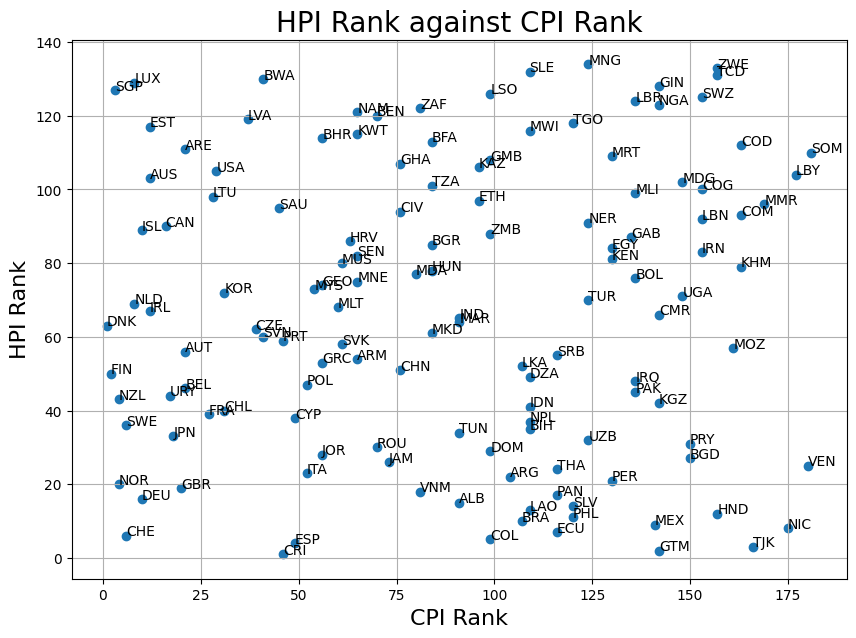

In [ ]:
#plotting HPI rank against CPI rank

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(merge_ISO['Rank'], merge_ISO['HPI rank'])

for _, row in merge_ISO.iterrows():
    plt.annotate(
        row['ISO'],
        (row['Rank'], row['HPI rank'])
    )

plt.xlabel('CPI Rank',fontsize=16)
plt.ylabel('HPI Rank',fontsize=16)
plt.title('HPI Rank against CPI Rank',fontsize=20)
plt.grid()
plt.show()

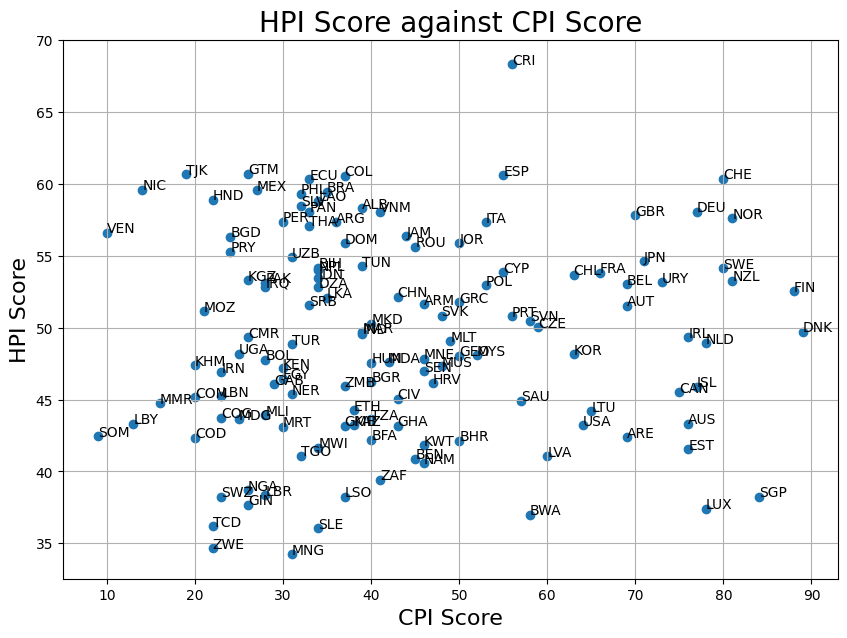

In [ ]:
#next I will plot  HPI score against the CPI score
plt.figure(figsize=(10, 7))

plt.scatter(merge_ISO['CPI 2025 score'], merge_ISO['HPI'])

for _, row in merge_ISO.iterrows():
    plt.annotate(
        row['ISO'],
        (row['CPI 2025 score'], row['HPI'])
    )

plt.xlabel('CPI Score',fontsize=16)
plt.ylabel('HPI Score',fontsize=16)
plt.title('HPI Score against CPI Score',fontsize=20)
plt.grid()
plt.show()

In [ ]:
#calculation of spearman and pearson correlation
# Starting with the ranks plot

pearson_rank = merge_ISO['Rank'].corr(
    merge_ISO['HPI rank'],
    method='pearson'
)

spearman_rank = merge_ISO['Rank'].corr(
    merge_ISO['HPI rank'],
    method='spearman'
)

print("Pearson rank:", round(pearson_rank, 4))
print("Spearman rank:", round(spearman_rank, 4))


Pearson rank: 0.0449
Spearman rank: 0.0504


In [ ]:
#calculating the same for scores
#next i will calculate the pearson correlation
pearson_score = merge_ISO['CPI 2025 score'].corr(
    merge_ISO['HPI'],
    method='pearson'
)

spearman_score = merge_ISO['CPI 2025 score'].corr(
    merge_ISO['HPI'],
    method='spearman'
)

print("Pearson score:", round(pearson_score, 4))
print("Spearman score:", round(spearman_score, 4))

Pearson score: 0.0559
Spearman score: 0.0504


For the rank plot, I think spearman correlation is a better option since spearman is a better option in ranked data. It provides the relationship between ordinal data and measures whether two values move together in the same direction or not and does not require linear data.

For the score plot, I would consider taking the pearson correlation since it is best used to measure linear relationships between raw data values.

The pearson values differ in the two plots while the spearman values remained the same across the two plots. The rank and score versions tell a similar story between the relationship of cpi and hpi. Both values are close to zero and are approximately o.o5. This shows that there is a very weak relationship almost neglible between cpi and hpi. It means a countries corruption does not directly affect the happiness level of the people in the country.

part c) Here I will be calculating the correlation between the components of hpi and CPI score.

In [ ]:
life_expentancy = merge_ISO['Life Expectancy'].corr(merge_ISO['CPI 2025 score'], method='pearson')

wellbeing = merge_ISO['Life satisfaction'].corr(merge_ISO['CPI 2025 score'], method='pearson')

ecological_footprint = merge_ISO['Ecological Footprint'].corr(merge_ISO['CPI 2025 score'], method='pearson')

print("Life expectancy vs CPI:", round(life_expentancy, 4))
print("Wellbeing vs CPI:", round(wellbeing, 4))
print("Ecological footprint vs CPI:", round(ecological_footprint, 4))

Life expectancy vs CPI: 0.6793
Wellbeing vs CPI: 0.6017
Ecological footprint vs CPI: 0.7337


In [ ]:
#displaying the component scores with the overall score

comparison = pd.DataFrame({
    'HPI measure': [
        'Overall HPI',
        'Life expectancy',
        'Wellbeing',
        'Ecological footprint'
    ],
    'Pearson correlation with CPI': [
        0.0559, #this value was calculated above under the pearson score
        life_expentancy,
        wellbeing,
        ecological_footprint
    ]
})

comparison['Pearson correlation with CPI'] = comparison['Pearson correlation with CPI'].round(4)


# Putting the results into a table for easy comparison
from tabulate import tabulate

# Prints a beautifully structured text table with a grid outline
print(tabulate(comparison, headers='keys', tablefmt='grid', showindex=False))

#The individual scores of hpi indicate a strong relationship with cpi. The calculation of overall hpi involves the use of all three components which negatively affect each other.
#When one component is lower or higher, it pulls the over hpi value down. However when using the individual components of hpi, these tend to have a higher value and are not affected by
#other factors

+----------------------+--------------------------------+
| HPI measure          |   Pearson correlation with CPI |
+======================+================================+
| Overall HPI          |                         0.0559 |
+----------------------+--------------------------------+
| Life expectancy      |                         0.6793 |
+----------------------+--------------------------------+
| Wellbeing            |                         0.6017 |
+----------------------+--------------------------------+
| Ecological footprint |                         0.7337 |
+----------------------+--------------------------------+


part d) Here I will calculate the difference between cpi and hpi and use this to identify the countries with the highest and lowest diffference in ranks.

In [ ]:
# I'll start by creating a new column in the data frame that has the difference between cpi and hpi ranks. I will subtract hpi from cpi.

merge_ISO['Rank Gap'] = merge_ISO['Rank'] - merge_ISO['HPI rank']

#I will then get the top 5 countries with the biggest difference for both negative and positive difference

#largest positive
largest_positive = merge_ISO.nlargest(5, 'Rank Gap')

#largest negatives
largest_negatives = merge_ISO.nsmallest(5, 'Rank Gap')

#returning only specific columns so that I can easily analyse the data basing on relevant fields

#print(largest_positive[['Country','Life Expectancy','Life satisfaction','Ecological Footprint', 'Rank', 'HPI rank', 'Rank Gap']])

#print( '\n',largest_negatives[['Country','Life Expectancy','Life satisfaction','Ecological Footprint', 'Rank', 'HPI rank', 'Rank Gap']])

#returning the data in a table for easy comparison

print(tabulate(largest_positive[['Country','Life Expectancy','Life satisfaction','Ecological Footprint', 'Rank', 'HPI rank', 'Rank Gap']], headers='keys', tablefmt='grid', showindex=False))

print(tabulate(largest_negatives[['Country','Life Expectancy','Life satisfaction','Ecological Footprint', 'Rank', 'HPI rank', 'Rank Gap']], headers='keys', tablefmt='grid', showindex=False))

+------------+-------------------+---------------------+------------------------+--------+------------+------------+
| Country    |   Life Expectancy |   Life satisfaction |   Ecological Footprint |   Rank |   HPI rank |   Rank Gap |
+============+===================+=====================+========================+========+============+============+
| Nicaragua  |            75.267 |             6.17109 |                1.79943 |    175 |          8 |        167 |
+------------+-------------------+---------------------+------------------------+--------+------------+------------+
| Tajikistan |            72.052 |             5.951   |                1.03    |    166 |          3 |        163 |
+------------+-------------------+---------------------+------------------------+--------+------------+------------+
| Venezuela  |            72.842 |             6.16799 |                1.93    |    180 |         25 |        155 |
+------------+-------------------+---------------------+--------